In [2]:
import numpy as np
import os
import glob
import yaml
import matplotlib.pyplot as plt
import fivebeads
import json

parent_dir = "/Volumes/Bit Bank 1/Research/Neural_Estimation/temp_dis2"
coarse_steps= ["01", "02", "04", "06", "08"]
num_trials = 12

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

folders = sorted([f for f in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, f))])


temp = []
for folder in folders:
    yaml_file_path = os.path.join(parent_dir, folder, "config.yaml")
    with open(yaml_file_path, "r") as file:
        config = yaml.safe_load(file)
    temp_sim = config.get('simulation', {}).get('kBT')[1]
    temp.append(temp_sim)
temp, folders

([1, 2, 4, 6, 8, 10],
 ['02_16_09_3310',
  '02_16_18_0402',
  '02_17_02_1249',
  '02_17_09_2833',
  '02_17_16_4800',
  '02_18_00_3016'])

In [3]:
r2 = np.zeros((len(temp), len(coarse_steps), 2, num_trials))
for folder in folders:
    file_path = os.path.join(parent_dir, folder, "theo_final_diss.npy")
    theo = np.load(file_path)
    for i in coarse_steps:
        file_path = os.path.join(parent_dir, folder, f"nn_final_diss_cum_coarse_{i}.npz")
        nn = np.load(file_path)
        r2_first=[]
        r2_second=[]
        for j in range(0,num_trials):
            r2_first.append(r2_score(theo[j,:],nn['first_order'].sum(axis=-1)[j,:]))
            r2_second.append(r2_score(theo[j,:],nn['second_order'].sum(axis=-1)[j,:]))
        r2[folders.index(folder), coarse_steps.index(i), 0,:] = r2_first
        r2[folders.index(folder), coarse_steps.index(i), 1,:] = r2_second




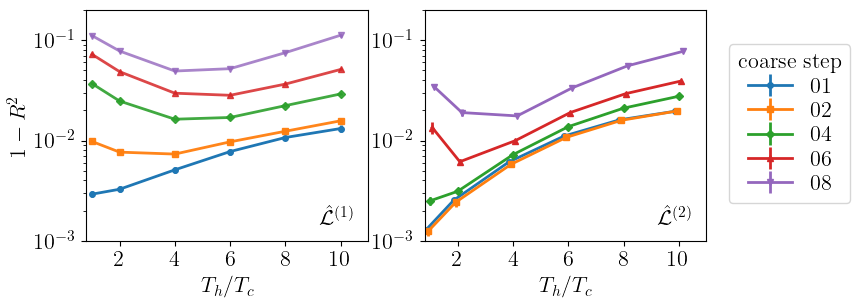

In [7]:
markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', '+', '|']
with open("plot_config.json", "r") as f:
    config = json.load(f)

# Apply settings to rcParams
plt.rcParams.update(config)
fig,ax = plt.subplots(1,2)
loc = 'upper right'


for i in coarse_steps:
    r2_mean = r2[:, coarse_steps.index(i), 0, :].mean(axis=1)
    r2_std = r2[:, coarse_steps.index(i), 0, :].std(axis=1)
    sorted_indices = np.argsort(temp)
    temp_sorted = np.array(temp)[sorted_indices]
    r2_mean_sorted = r2_mean[sorted_indices]
    r2_std_sorted = r2_std[sorted_indices]    
    ax[0].errorbar(temp_sorted, 1-r2_mean_sorted, yerr=r2_std_sorted, label=f"{i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1-0.05*coarse_steps.index(i))
    #ax[0].legend(title="coarse-grained step",title_fontsize=16, ncol=3, loc="upper right", fontsize=16)
    #plt.xscale('log')
    ax[0].set_yscale('log')
    ax[0].set_xlim([0.8, 11])
    ax[0].set_ylim([0.001, 0.2])
ax[0].set_xlabel("$T_h/T_c$")
ax[0].set_ylabel("$1-R^2$")
ax[0].set_xticks(np.array([2,4,6,8,10]))
ax[0].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(1)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[0].transAxes)



num_coarse = len(coarse_steps)
offset = np.linspace(-.15,.15,num_coarse)
for j,i in enumerate(coarse_steps):
    r2_mean = r2[:, coarse_steps.index(i), 1, :].mean(axis=1)
    r2_std = r2[:, coarse_steps.index(i), 1, :].std(axis=1)
    ############
    sorted_indices = np.argsort(temp)
    temp_sorted = np.array(temp)[sorted_indices]
    r2_mean_sorted = r2_mean[sorted_indices]
    r2_std_sorted = r2_std[sorted_indices]  
    ###########
    ax[1].errorbar(temp_sorted+offset[j], 1-r2_mean_sorted, yerr=r2_std_sorted, label=f"{i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    ax[1].legend(title="coarse step", ncol=1, loc="upper right", bbox_to_anchor=(1.55, 0.9))
    #plt.xscale('log')
    ax[1].set_yscale('log')
    ax[1].set_xlim([0.8, 11])
    ax[1].set_ylim([0.001, 0.2])
    ax[1].xticks = temp_sorted
ax[1].set_xlabel("$T_h/T_c$")
ax[1].set_xticks(np.array([2,4,6,8,10]))

#ax[1].set_ylabel("$1-R^2$")
ax[1].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(2)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[1].transAxes)


plt.savefig("figs/r2_temp_dis2.pdf",bbox_inches='tight')



### entropy mean


In [8]:
ent_mean = np.zeros((len(temp),len(coarse_steps), 2, num_trials))
for folder in folders:
    file_path = os.path.join(parent_dir, folder, "theo_final_diss.npy")
    theo = np.load(file_path).mean()
    for i in coarse_steps:
        file_path = os.path.join(parent_dir, folder, f"nn_final_diss_cum_coarse_{i}.npz")
        nn = np.load(file_path)
        ent_mean[folders.index(folder), coarse_steps.index(i), 0,:] = (nn["first_order"].sum(axis=-1).mean(axis=1))/theo
        ent_mean[folders.index(folder), coarse_steps.index(i), 1,:] = (nn["second_order"].sum(axis=-1).mean(axis=1))/theo

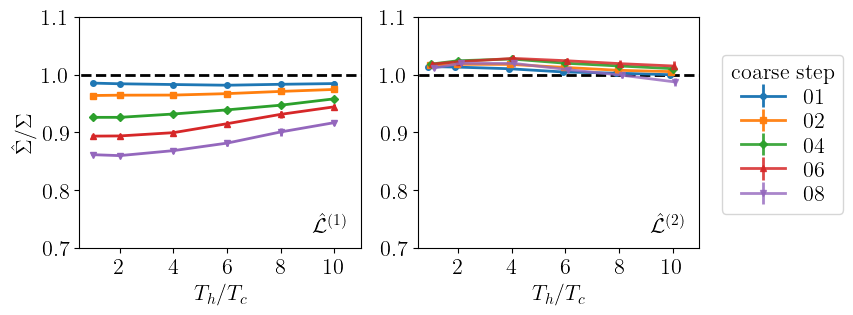

In [9]:
markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', '+', '|']
fig,ax = plt.subplots(1,2)
for i in coarse_steps:
    mean = ent_mean[:, coarse_steps.index(i), 0, :].mean(axis=1)
    std = ent_mean[:, coarse_steps.index(i), 0, :].std(axis=1)
    ############
    sorted_indices = np.argsort(temp)
    N_sorted = np.array(temp)[sorted_indices]
    mean_sorted = mean[sorted_indices]
    std_sorted = std[sorted_indices]  
    ###########
    ax[0].errorbar(N_sorted, mean_sorted, yerr=std_sorted, label=f"1st order, coarse step {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1)
    #ax[0].legend(loc='upper left')
    #plt.xscale('log')
    ax[0].set_xlim([0.5, 11])
    ax[0].set_ylim([0.7, 1.1])
    #ax[0].set_yscale('log')
ax[0].plot([0, 11], [1,1], 'k--')
ax[0].set_xlabel("$T_h/T_c$")
ax[0].set_ylabel(r"$\hat{\Sigma}/\Sigma$")
ax[0].set_xticks(np.array([2,4,6,8,10]))


ax[0].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(1)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[0].transAxes)

#plt.savefig("figs/ent_first_order_dis2.pdf")
num_coarse = len(coarse_steps)
offset = np.linspace(-.10,.10,num_coarse)
for j,i in enumerate(coarse_steps):
    mean = ent_mean[:, coarse_steps.index(i), 1, :].mean(axis=1)
    std = ent_mean[:, coarse_steps.index(i), 1, :].std(axis=1)
    ############
    sorted_indices = np.argsort(temp)
    temp_sorted = np.array(temp)[sorted_indices]
    mean_sorted = mean[sorted_indices]
    std_sorted = std[sorted_indices]  
    ###########
    ax[1].errorbar(temp_sorted+offset[j], mean_sorted, yerr=std_sorted, label=f" {i}", marker=markers[coarse_steps.index(i)], markersize=4, linewidth=2, alpha=1- coarse_steps.index(i)*0.05)
    ax[1].legend(loc='lower right', bbox_to_anchor=(1.55, 0.1), title="coarse step", ncol=1)
    #plt.xscale('log')
    ax[1].set_xlim([0.5, 11])
    ax[1].set_ylim([0.7, 1.1])
    #ax[1].set_yscale('log')
ax[1].plot([0, 11], [1,1], 'k--')
ax[1].set_xlabel("$T_h/T_c$")
ax[1].text(0.95, 0.05, r'$\hat{\mathcal{L}}^{(2)}$', horizontalalignment='right', verticalalignment='bottom', transform=ax[1].transAxes)
ax[1].set_xticks(np.array([2,4,6,8,10]))

#plt.ylabel("$\hat{\Sigma}/\Sigma$")
plt.savefig("figs/ent_temp_dis2.pdf",bbox_inches='tight')